In [57]:
!pip install -q xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [58]:
df = pd.read_csv("/content/diabetic_data.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [59]:
print("Columns:")
print(df.columns.tolist())

print("\nDataset information:")
print(df.info())

print("\nTarget distribution:")
print(df["readmitted"].value_counts())

Columns:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null 

In [60]:
df = df.replace("?", np.nan)

print("Total missing values:")
print(df.isnull().sum().sum())

Total missing values:
374017


In [61]:
columns_to_drop = [
    "encounter_id",
    "patient_nbr",
    "weight",
    "payer_code",
    "medical_specialty"
]

df = df.drop(
    columns=columns_to_drop,
    errors="ignore"
)

print("New dataset shape:", df.shape)

New dataset shape: (101766, 45)


In [62]:
df["readmitted"] = df["readmitted"].apply(
    lambda x: 0 if x == "NO" else 1
)

print("Target distribution:")
print(df["readmitted"].value_counts())

print("\nTarget percentage:")
print(df["readmitted"].value_counts(normalize=True) * 100)

Target distribution:
readmitted
0    54864
1    46902
Name: count, dtype: int64

Target percentage:
readmitted
0    53.911916
1    46.088084
Name: proportion, dtype: float64


In [63]:
X = df.drop("readmitted", axis=1)
y = df["readmitted"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (101766, 44)
Target shape: (101766,)


In [64]:
for column in X.columns:

    if X[column].dtype == "object":
        X[column] = X[column].fillna(
            X[column].mode()[0]
        )
    else:
        X[column] = X[column].fillna(
            X[column].median()
        )

print(
    "Remaining missing values:",
    X.isnull().sum().sum()
)

Remaining missing values: 0


In [76]:
# ==========================================
# 9. ONE-HOT ENCODING
# ==========================================

X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=np.float32
)

# Fix XGBoost feature-name error
# Replace [, ], <, > with _
X.columns = (
    X.columns
    .astype(str)
    .str.replace("[", "_", regex=False)
    .str.replace("]", "_", regex=False)
    .str.replace("<", "_", regex=False)
    .str.replace(">", "_", regex=False)
)

print("Encoded feature shape:", X.shape)

print("\nFirst 10 feature names:")
print(X.columns[:10].tolist())

Encoded feature shape: (101766, 2330)

First 10 feature names:
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient']


In [77]:
# ==========================================
# 10. CONVERT DATA TYPES
# ==========================================

X = X.astype(np.float32)
y = y.astype(np.int8)

print("X data type:")
print(X.dtypes.value_counts())

print("\ny data type:")
print(y.dtype)

X data type:
float32    2330
Name: count, dtype: int64

y data type:
int8


In [78]:
# ==========================================
# 11. TRAIN-TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (81412, 2330)
Testing data: (20354, 2330)

Training target distribution:
readmitted
0    43891
1    37521
Name: count, dtype: int64

Testing target distribution:
readmitted
0    10973
1     9381
Name: count, dtype: int64


In [80]:
# ==========================================
# 12. CLASS IMBALANCE
# ==========================================

negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Negative samples:", negative)
print("Positive samples:", positive)
print("Scale Pos Weight:", scale_pos_weight)

Negative samples: 43891
Positive samples: 37521
Scale Pos Weight: 1.1697715945737055


In [81]:


# ==========================================
# 13. CREATE XGBOOST MODEL
# ==========================================

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.7,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=2,
    tree_method="hist"
)

print("XGBoost model created successfully!")

XGBoost model created successfully!


In [82]:
# ==========================================
# 14. TRAIN MODEL
# ==========================================

print("Starting XGBoost training...")
print("Training samples:", X_train.shape[0])
print("Features:", X_train.shape[1])

model.fit(
    X_train,
    y_train,
    verbose=False
)

print("Training completed successfully!")

Starting XGBoost training...
Training samples: 81412
Features: 2330
Training completed successfully!


In [83]:
# ==========================================
# 15. PREDICTIONS
# ==========================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

print("\nFirst 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 probabilities:")
print(y_prob[:10])

Predictions generated successfully!

First 10 predictions:
[1 0 0 0 0 1 1 0 1 1]

First 10 probabilities:
[0.5290625  0.480284   0.496779   0.32856217 0.3707294  0.77688205
 0.73707384 0.4993096  0.7041349  0.5891726 ]


In [84]:
# ==========================================
# 16. ACCURACY
# ==========================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.6401690085486882


In [85]:
# ==========================================
# 17. CLASSIFICATION REPORT
# ==========================================

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Not Readmitted",
            "Readmitted"
        ]
    )
)

                precision    recall  f1-score   support

Not Readmitted       0.66      0.69      0.68     10973
    Readmitted       0.62      0.58      0.60      9381

      accuracy                           0.64     20354
     macro avg       0.64      0.64      0.64     20354
  weighted avg       0.64      0.64      0.64     20354



Confusion Matrix:
[[7624 3349]
 [3975 5406]]


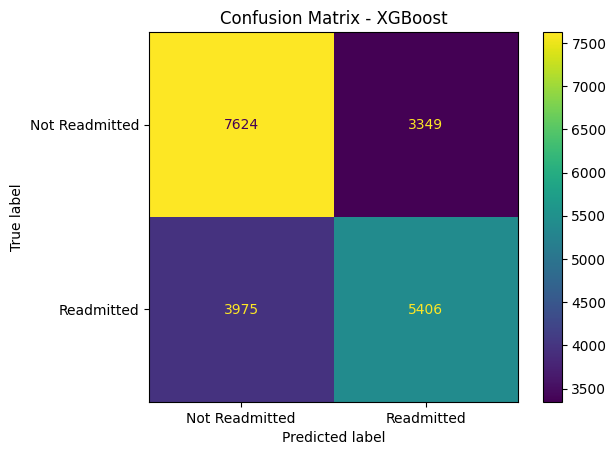

In [86]:
# ==========================================
# 18. CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Not Readmitted",
        "Readmitted"
    ]
)

disp.plot()

plt.title("Confusion Matrix - XGBoost")
plt.show()

In [87]:
# ==========================================
# 19. ROC-AUC
# ==========================================

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.6936817850227546


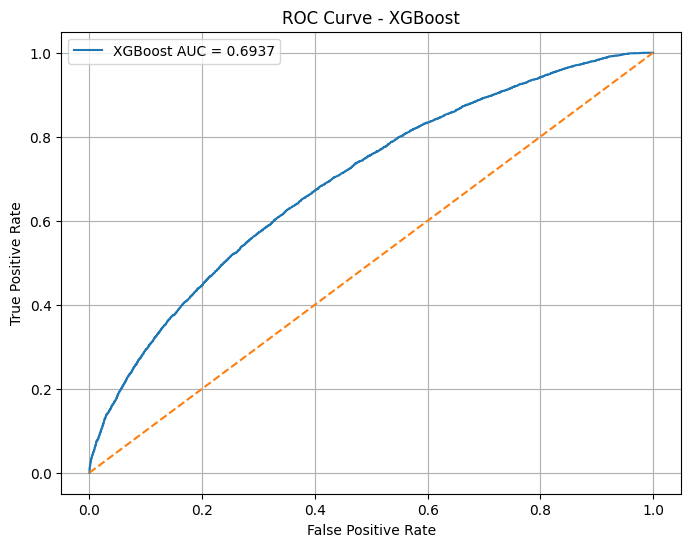

In [88]:
# ==========================================
# 20. ROC CURVE
# ==========================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - XGBoost")

plt.legend()
plt.grid()

plt.show()

In [89]:
# ==========================================
# 21. PRECISION-RECALL AUC
# ==========================================

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

pr_auc = average_precision_score(
    y_test,
    y_prob
)

print("Average Precision / PR-AUC:", pr_auc)

Average Precision / PR-AUC: 0.6557104720066086


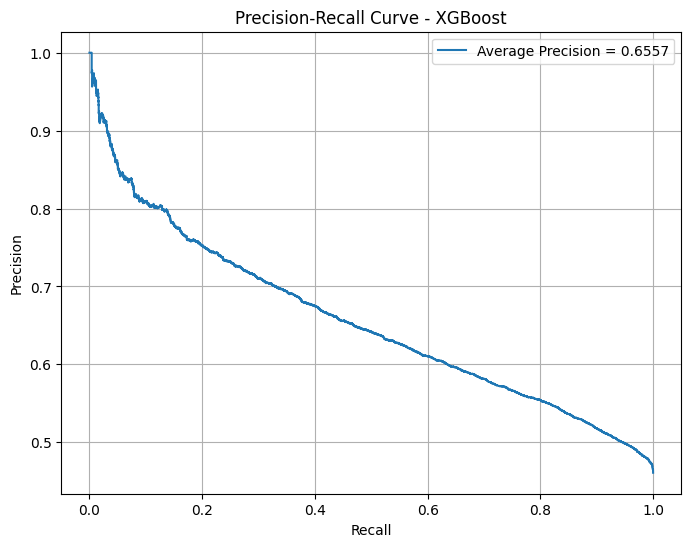

In [90]:
# ==========================================
# 22. PRECISION-RECALL CURVE
# ==========================================

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"Average Precision = {pr_auc:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve - XGBoost")

plt.legend()
plt.grid()

plt.show()

In [91]:
# ==========================================
# 23. FEATURE IMPORTANCE
# ==========================================

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(
    ascending=False
)

print("Top 20 important features:")
print(importance.head(20))

Top 20 important features:
number_inpatient            0.128615
number_diagnoses            0.040846
number_outpatient           0.038279
discharge_disposition_id    0.033319
diag_1_428                  0.032861
number_emergency            0.031593
diabetesMed_Yes             0.023476
admission_source_id         0.022432
age__70-80)                 0.017587
diag_1_278                  0.017037
diag_2_250                  0.016004
diag_2_648                  0.015333
diag_2_491                  0.014581
diag_1_491                  0.013757
diag_2_403                  0.013754
diag_2_428                  0.013438
diag_3_428                  0.013333
diag_1_250.6                0.012833
diag_2_401                  0.011818
num_medications             0.011450
dtype: float32


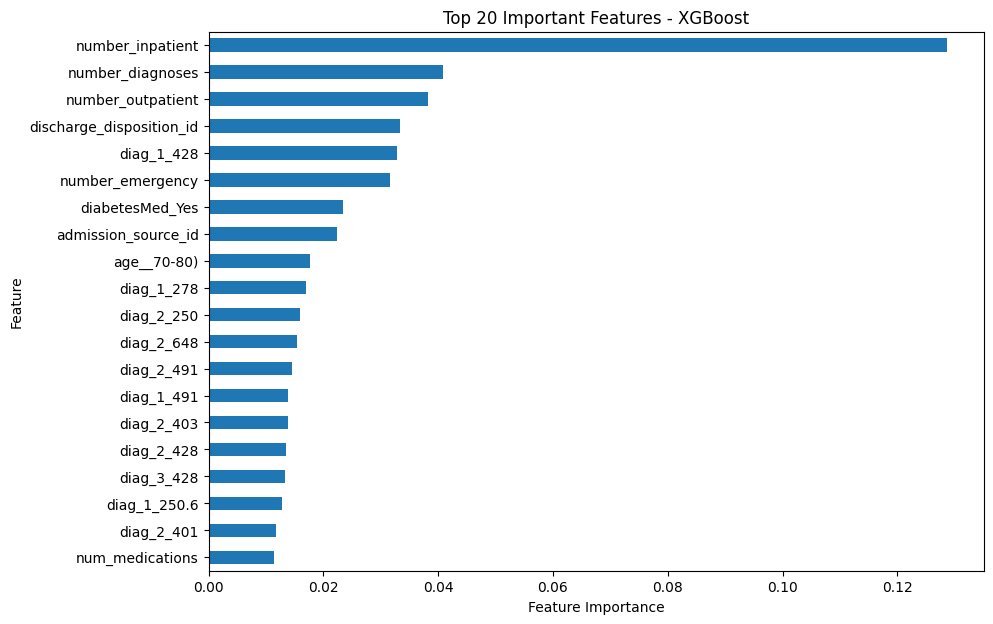

In [92]:
# ==========================================
# 24. FEATURE IMPORTANCE PLOT
# ==========================================

plt.figure(figsize=(10, 7))

importance.head(20).sort_values().plot(
    kind="barh"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title("Top 20 Important Features - XGBoost")

plt.show()